<a href="https://colab.research.google.com/github/NSF-DARSE/YolktoFeed/blob/main/JupyterNotebook/liverHEDI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [151]:
import pandas as pd
import sys
import numpy as np

In [152]:
path = "/content/drive/Shareddrives/NSF-SCIPE-DARSE/Research Software Engineers (RSE)/Abhin/Projects/Carl Schmidt"
sys.path.append(path)

In [153]:
df_base = pd.read_csv(path+"/Liver_HEIDI_complete_ensembl_symbol.csv")

In [154]:
print("Number of genes: ", df_base.shape[0])

# finding last row with valid gene symbol
gene_list_last_index = (df_base["Gene Symbol"] == "-").idxmax()

print("Number of nan's: ", df_base.iloc[:,2:].apply(pd.to_numeric, errors='coerce').isna().sum().sum())

Number of genes:  24869
Number of nan's:  0


In [160]:
#truncating till that row
df_trunk = df_base.copy()

#df_trunk = df_base.iloc[:gene_list_last_index]
#df_trunk = df_trunk.drop(columns=["Ensembl Gene ID"])
#df_trunk = df_trunk.set_index("Gene Symbol")

df_trunk.index = df_trunk['Gene Symbol'].replace('-', pd.NA).fillna(df_trunk['Ensembl Gene ID'])


df_trunk

,Ensembl Gene ID,Gene Symbol,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,ENSGALG00000008988,ZZZ3,2.14867,4.20406,3.60938,6.67723,3.84912,7.35415,5.04080,3.03153,...,0.970587,1.66351,1.63658,2.45922,4.89339,2.48960,3.19717,1.46844,2.09156,0.187683
ZYX,ENSGALG00000014688,ZYX,24.36620,32.56920,31.25390,37.84720,37.69280,56.60480,33.38570,27.91830,...,13.140900,24.40290,25.38120,28.66670,34.74150,22.50770,29.35630,25.15260,34.86540,12.079700
ZXDC,ENSGALG00000030487,ZXDC,2.03248,2.47147,1.54310,3.03772,1.77186,4.07981,2.90018,2.16172,...,0.945374,1.22140,1.27156,2.26309,2.27403,1.65132,2.59244,2.71500,2.81808,0.710741
ZW10,ENSGALG00000040155,ZW10,4.83476,7.15083,5.56367,10.11710,5.90561,12.05200,9.86982,6.42687,...,2.026740,3.13406,4.48471,5.77671,8.31175,4.39192,6.41727,4.31607,5.51881,1.944010
ZUFSP,ENSGALG00000014940,ZUFSP,3.17070,2.90837,2.35482,3.34666,2.56477,3.13315,4.45418,3.49699,...,2.675900,1.74104,1.22244,3.35882,3.35107,2.99852,2.41147,1.65847,2.00354,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSGALG00000033139,ENSGALG00000033139,-,1574.11000,2959.14000,3883.51000,412.85100,4080.86000,1799.89000,360.72300,1174.50000,...,1370.840000,2138.51000,3842.98000,3690.71000,2006.21000,1936.23000,2879.06000,2275.96000,3987.26000,4260.360000
ENSGALG00000043598,ENSGALG00000043598,-,22943.20000,4386.13000,5211.58000,4751.88000,7874.62000,5552.93000,5923.33000,7055.88000,...,2505.860000,5090.91000,1788.57000,1330.63000,2228.85000,1292.86000,1212.52000,1336.66000,1804.92000,2092.840000
ENSGALG00000036956,ENSGALG00000036956,-,22066.10000,9040.49000,7030.17000,5656.09000,9497.06000,11204.50000,5603.51000,7056.97000,...,4430.480000,4264.87000,4099.04000,3331.48000,3193.70000,2750.76000,2632.46000,2705.28000,3260.77000,3437.780000


In [127]:
type(df_trunk)

pandas.core.frame.DataFrame

In [161]:
#droping day 6
omit_days = [6]
drop_days=tuple(['_'+str(day) for day in omit_days])
df_trunk = df_trunk.loc[:, ~df_trunk.columns.str.endswith(drop_days)]
df_trunk

,Ensembl Gene ID,Gene Symbol,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,ENSGALG00000008988,ZZZ3,2.14867,4.20406,3.60938,6.67723,3.84912,7.35415,5.04080,3.03153,...,0.970587,1.66351,1.63658,2.45922,4.89339,2.48960,3.19717,1.46844,2.09156,0.187683
ZYX,ENSGALG00000014688,ZYX,24.36620,32.56920,31.25390,37.84720,37.69280,56.60480,33.38570,27.91830,...,13.140900,24.40290,25.38120,28.66670,34.74150,22.50770,29.35630,25.15260,34.86540,12.079700
ZXDC,ENSGALG00000030487,ZXDC,2.03248,2.47147,1.54310,3.03772,1.77186,4.07981,2.90018,2.16172,...,0.945374,1.22140,1.27156,2.26309,2.27403,1.65132,2.59244,2.71500,2.81808,0.710741
ZW10,ENSGALG00000040155,ZW10,4.83476,7.15083,5.56367,10.11710,5.90561,12.05200,9.86982,6.42687,...,2.026740,3.13406,4.48471,5.77671,8.31175,4.39192,6.41727,4.31607,5.51881,1.944010
ZUFSP,ENSGALG00000014940,ZUFSP,3.17070,2.90837,2.35482,3.34666,2.56477,3.13315,4.45418,3.49699,...,2.675900,1.74104,1.22244,3.35882,3.35107,2.99852,2.41147,1.65847,2.00354,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSGALG00000033139,ENSGALG00000033139,-,1574.11000,2959.14000,3883.51000,412.85100,4080.86000,1799.89000,360.72300,1174.50000,...,1370.840000,2138.51000,3842.98000,3690.71000,2006.21000,1936.23000,2879.06000,2275.96000,3987.26000,4260.360000
ENSGALG00000043598,ENSGALG00000043598,-,22943.20000,4386.13000,5211.58000,4751.88000,7874.62000,5552.93000,5923.33000,7055.88000,...,2505.860000,5090.91000,1788.57000,1330.63000,2228.85000,1292.86000,1212.52000,1336.66000,1804.92000,2092.840000
ENSGALG00000036956,ENSGALG00000036956,-,22066.10000,9040.49000,7030.17000,5656.09000,9497.06000,11204.50000,5603.51000,7056.97000,...,4430.480000,4264.87000,4099.04000,3331.48000,3193.70000,2750.76000,2632.46000,2705.28000,3260.77000,3437.780000


In [162]:
meta_cols = ['Gene Symbol', 'Ensembl Gene ID']
expr_cols = [c for c in df_trunk.columns if c not in meta_cols]

sample_meta = pd.DataFrame({'Sample': expr_cols})
sample_meta['Day'] = sample_meta['Sample'].str.extract(r'_(\d+)$').astype(int)
#display(sample_meta)

DAYS = sorted(sample_meta['Day'].unique().tolist())
#days = df_trunk.iloc[:,2:].columns.str.extract(r'_(\d+)$')
DAYS

[4, 8, 10, 12, 14, 16, 18, 20]

In [176]:
sample_cols = df_trunk.columns[2:]

X = df_trunk[expr_cols]
expressed = X > 0.1

days = sample_cols.str.extract(r'_(\d+)$')[0].values

counts_by_day = expressed.T.groupby(days).sum().T

#keep = (counts_by_day >= 5).any(axis=1)
keep = (counts_by_day >= 5).all(axis=1)

df_filtered = df_trunk.loc[keep].reset_index(drop=True)

print(df_filtered.shape)

(13419, 96)


In [179]:
#df_filtered = df_filtered.set_index("Gene Symbol")
df_filtered.index = df_filtered['Gene Symbol'].replace('-', pd.NA).fillna(df_filtered['Ensembl Gene ID'])
#df_filtered = df_filtered.set_index("Gene Symbol")
df_filtered

,Ensembl Gene ID,Gene Symbol,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,ENSGALG00000008988,ZZZ3,2.14867,4.20406,3.60938,6.67723,3.84912,7.35415,5.04080,3.03153,...,0.970587,1.66351,1.63658,2.45922,4.89339,2.48960,3.19717,1.46844,2.09156,0.187683
ZYX,ENSGALG00000014688,ZYX,24.36620,32.56920,31.25390,37.84720,37.69280,56.60480,33.38570,27.91830,...,13.140900,24.40290,25.38120,28.66670,34.74150,22.50770,29.35630,25.15260,34.86540,12.079700
ZXDC,ENSGALG00000030487,ZXDC,2.03248,2.47147,1.54310,3.03772,1.77186,4.07981,2.90018,2.16172,...,0.945374,1.22140,1.27156,2.26309,2.27403,1.65132,2.59244,2.71500,2.81808,0.710741
ZW10,ENSGALG00000040155,ZW10,4.83476,7.15083,5.56367,10.11710,5.90561,12.05200,9.86982,6.42687,...,2.026740,3.13406,4.48471,5.77671,8.31175,4.39192,6.41727,4.31607,5.51881,1.944010
ZUFSP,ENSGALG00000014940,ZUFSP,3.17070,2.90837,2.35482,3.34666,2.56477,3.13315,4.45418,3.49699,...,2.675900,1.74104,1.22244,3.35882,3.35107,2.99852,2.41147,1.65847,2.00354,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSGALG00000033139,ENSGALG00000033139,-,1574.11000,2959.14000,3883.51000,412.85100,4080.86000,1799.89000,360.72300,1174.50000,...,1370.840000,2138.51000,3842.98000,3690.71000,2006.21000,1936.23000,2879.06000,2275.96000,3987.26000,4260.360000
ENSGALG00000043598,ENSGALG00000043598,-,22943.20000,4386.13000,5211.58000,4751.88000,7874.62000,5552.93000,5923.33000,7055.88000,...,2505.860000,5090.91000,1788.57000,1330.63000,2228.85000,1292.86000,1212.52000,1336.66000,1804.92000,2092.840000
ENSGALG00000036956,ENSGALG00000036956,-,22066.10000,9040.49000,7030.17000,5656.09000,9497.06000,11204.50000,5603.51000,7056.97000,...,4430.480000,4264.87000,4099.04000,3331.48000,3193.70000,2750.76000,2632.46000,2705.28000,3260.77000,3437.780000


In [61]:
expressed.T.groupby(days).sum().T

,10,12,14,16,18,20,4,8
0,12,12,11,12,12,12,11,12
1,12,12,11,12,12,12,11,12
2,12,12,11,11,12,12,11,12
3,12,12,11,12,12,12,11,12
4,12,12,11,12,12,12,11,12
...,...,...,...,...,...,...,...,...
24864,12,12,11,12,12,12,11,12
24865,12,12,11,12,12,12,11,12
24866,12,12,11,12,12,12,11,12
24867,12,12,11,12,12,12,11,12


In [154]:
#df_trunk.insert(0, "avg", df_trunk.iloc[:, :].sum(axis=1)/(df_trunk.shape[1]-1))
#df_trunk.insert(1, "sigma", df_trunk.iloc[:,:].var(axis=1))
#df_trunk.insert(2, "max", df_trunk.iloc[:,:].max(axis=1))
#df_trunk

In [155]:
#df_trunk = df_trunk[(df_trunk.loc[:,'avg'] > 1e-1)]
#df_trunk

In [156]:
#df_trunk = df_trunk[(df_trunk.loc[:,'sigma'] > 1e-1)]
#df_trunk

In [180]:
from collections import Counter
Counter(sample_meta['Day'].tolist())

Counter({4: 11, 8: 12, 10: 12, 12: 12, 14: 11, 16: 12, 18: 12, 20: 12})

## PCA Analysis

In [181]:
expr = df_filtered[expr_cols].copy()
#expr = expr.T
expr

,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,1673_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,2.14867,4.20406,3.60938,6.67723,3.84912,7.35415,5.04080,3.03153,2.72121,3.94125,...,0.970587,1.66351,1.63658,2.45922,4.89339,2.48960,3.19717,1.46844,2.09156,0.187683
ZYX,24.36620,32.56920,31.25390,37.84720,37.69280,56.60480,33.38570,27.91830,34.05230,57.31100,...,13.140900,24.40290,25.38120,28.66670,34.74150,22.50770,29.35630,25.15260,34.86540,12.079700
ZXDC,2.03248,2.47147,1.54310,3.03772,1.77186,4.07981,2.90018,2.16172,2.23018,4.59681,...,0.945374,1.22140,1.27156,2.26309,2.27403,1.65132,2.59244,2.71500,2.81808,0.710741
ZW10,4.83476,7.15083,5.56367,10.11710,5.90561,12.05200,9.86982,6.42687,5.54391,8.63428,...,2.026740,3.13406,4.48471,5.77671,8.31175,4.39192,6.41727,4.31607,5.51881,1.944010
ZUFSP,3.17070,2.90837,2.35482,3.34666,2.56477,3.13315,4.45418,3.49699,2.42156,2.14063,...,2.675900,1.74104,1.22244,3.35882,3.35107,2.99852,2.41147,1.65847,2.00354,0.645755
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSGALG00000033139,1574.11000,2959.14000,3883.51000,412.85100,4080.86000,1799.89000,360.72300,1174.50000,3449.52000,3847.02000,...,1370.840000,2138.51000,3842.98000,3690.71000,2006.21000,1936.23000,2879.06000,2275.96000,3987.26000,4260.360000
ENSGALG00000043598,22943.20000,4386.13000,5211.58000,4751.88000,7874.62000,5552.93000,5923.33000,7055.88000,6417.16000,4094.76000,...,2505.860000,5090.91000,1788.57000,1330.63000,2228.85000,1292.86000,1212.52000,1336.66000,1804.92000,2092.840000
ENSGALG00000036956,22066.10000,9040.49000,7030.17000,5656.09000,9497.06000,11204.50000,5603.51000,7056.97000,8836.09000,9392.20000,...,4430.480000,4264.87000,4099.04000,3331.48000,3193.70000,2750.76000,2632.46000,2705.28000,3260.77000,3437.780000


In [182]:
log_expr_vals = np.log2(expr.values + 1)
log_expr = pd.DataFrame(log_expr_vals, index=expr.index, columns=expr.columns)
log_expr

,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,1673_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,1.654743,2.379638,2.204573,2.940586,2.277723,3.062493,2.594740,2.011327,1.895772,2.304876,...,0.978625,1.413329,1.398668,1.790447,2.559098,1.803062,2.069417,1.303600,1.628335,0.248150
ZYX,4.664836,5.069066,5.011402,5.279739,5.273993,5.848117,5.103737,4.853911,5.131437,5.865696,...,3.821802,4.666921,4.721438,4.890773,5.159528,4.555061,4.923924,4.708882,5.164521,3.709258
ZXDC,1.600498,1.795547,1.346588,2.013541,1.470854,2.344775,1.963541,1.660710,1.691615,2.484605,...,0.960048,1.151469,1.183683,1.706239,1.711068,1.406711,1.844964,1.893362,1.932847,0.774621
ZW10,2.544673,3.026947,2.714503,3.474709,2.787769,3.706199,3.442256,2.892754,2.710153,3.268177,...,1.597765,2.047559,2.455415,2.760585,3.219052,2.430799,2.890888,2.410360,2.704609,1.557783
ZUFSP,2.060290,1.966567,1.746235,2.119907,1.833809,2.047242,2.447362,2.168960,1.774654,1.651054,...,1.878098,1.454723,1.152144,2.123938,2.121370,1.999466,1.770394,1.410596,1.586664,0.718750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSGALG00000033139,10.621237,11.531450,11.923517,8.692968,11.995011,10.814494,8.498742,10.199059,11.752598,11.909901,...,10.421897,11.063065,11.908385,11.850074,10.970976,10.919780,11.491883,11.152893,11.961544,12.057098
ENSGALG00000043598,14.485842,12.099062,12.347782,12.214586,12.943178,12.439293,12.532436,12.784815,12.647944,11.999915,...,11.291666,12.313991,10.805397,10.378978,11.122731,10.337466,10.244982,10.385496,10.818518,11.031935
ENSGALG00000036956,14.429609,13.142345,12.779549,12.465844,13.213417,13.451919,12.452373,12.785038,13.109356,13.197401,...,12.113573,12.058624,12.001422,11.702381,11.641465,11.426139,11.362744,11.402095,11.671439,11.747681


In [183]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_t        = log_expr.T.values.astype(float)
X_t_scaled = StandardScaler().fit_transform(X_t)

pca_t = PCA(n_components=10, random_state=42)
Xpca  = pca_t.fit_transform(X_t_scaled)

print(f"  PC1 explains: {pca_t.explained_variance_ratio_[0]*100:.1f}% of variance")
print(f"  PC2 explains: {pca_t.explained_variance_ratio_[1]*100:.1f}% of variance")
print(f"  PC3 explains: {pca_t.explained_variance_ratio_[2]*100:.1f}% of variance")
print(f"  PC4 explains: {pca_t.explained_variance_ratio_[3]*100:.1f}% of variance")
print(f"  Xpca shape  : {Xpca.shape}")

  PC1 explains: 42.9% of variance
  PC2 explains: 9.4% of variance
  PC3 explains: 5.7% of variance
  PC4 explains: 4.0% of variance
  Xpca shape  : (94, 10)


In [130]:
type(pca_t)

sklearn.decomposition._pca.PCA

In [125]:
DAY_COLORS = {
    4:  '#2ecc71',   # green
    6:  '#27ae60',   # dark green
    8:  '#f1c40f',   # yellow
    10: '#e67e22',   # orange
    12: '#e74c3c',   # red
    14: '#8e44ad',   # PURPLE ← Day 14
    16: '#3498db',   # blue
    18: '#1abc9c',   # teal
    20: '#2c3e50',   # dark navy
}

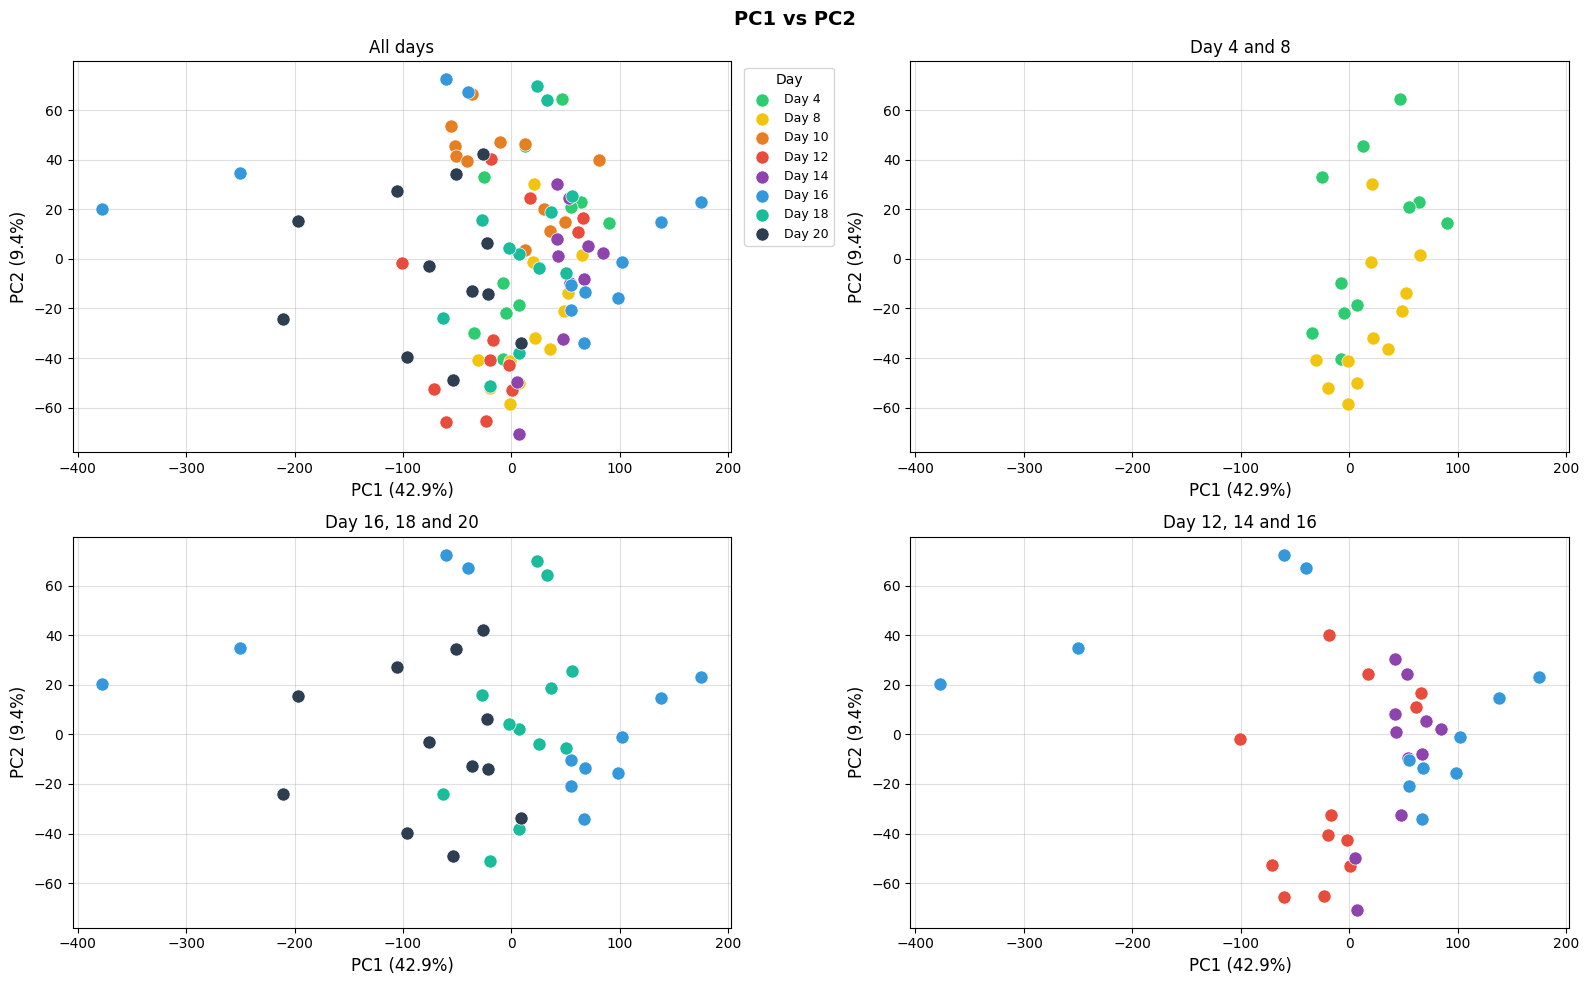

In [184]:
import matplotlib.pyplot as plt
import numpy as np
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PC1 vs PC2',
             fontsize=14, fontweight='bold')
ax1 = axes[0,0]
for day in DAYS:
    idx = np.where(sample_meta['Day'].values == day)[0]
    ax1.scatter(Xpca[idx, 0], Xpca[idx, 1],
               c=DAY_COLORS[day], label=f'Day {day}',
               s=90, edgecolors='white', linewidth=0.5, zorder=3)

d14_idx = np.where(sample_meta['Day'].values == 14)[0]
ax1.set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax1.set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax1.set_title('All days', fontsize=12)
ax1.legend(title='Day', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax1.grid(True, alpha=0.4)

ax2 = axes[0,1]
for day in [4, 8]:
    idx = np.where(sample_meta['Day'].values == day)[0]
    ax2.scatter(Xpca[idx, 0], Xpca[idx, 1],
               c=DAY_COLORS[day], label=f'Day {day}',
               s=90, edgecolors='white', linewidth=0.5, zorder=3)

    ax2.set_xlim(ax1.get_xlim())
    ax2.set_ylim(ax1.get_ylim())
ax2.set_title('Day 4 and 8', fontsize=12)
ax2.set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax2.set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax2.grid(True, alpha=0.4)

ax3 = axes[1,0]
for day in [16, 18, 20]:
    idx = np.where(sample_meta['Day'].values == day)[0]
    ax3.scatter(Xpca[idx, 0], Xpca[idx, 1],
               c=DAY_COLORS[day], label=f'Day {day}',
               s=90, edgecolors='white', linewidth=0.5, zorder=3)

    ax3.set_xlim(ax1.get_xlim())
    ax3.set_ylim(ax1.get_ylim())
ax3.set_title('Day 16, 18 and 20', fontsize=12)
ax3.set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax3.set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax3.grid(True, alpha=0.4)

ax4 = axes[1,1]
for day in [12, 14, 16]:
    idx = np.where(sample_meta['Day'].values == day)[0]
    ax4.scatter(Xpca[idx, 0], Xpca[idx, 1],
               c=DAY_COLORS[day], label=f'Day {day}',
               s=90, edgecolors='white', linewidth=0.5, zorder=3)

    ax4.set_xlim(ax1.get_xlim())
    ax4.set_ylim(ax1.get_ylim())
ax4.set_title('Day 12, 14 and 16', fontsize=12)
ax4.set_xlabel(f'PC1 ({pca_t.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax4.set_ylabel(f'PC2 ({pca_t.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax4.grid(True, alpha=0.4)

plt.tight_layout()

In [132]:
from scipy import stats

In [185]:
days_a=[4,8]
days_b=[16]
day_a_samples = sample_meta[sample_meta['Day'].isin(days_a)]['Sample'].tolist()
day_b_samples = sample_meta[sample_meta['Day'].isin(days_b)]['Sample'].tolist()

day_a_mean   = log_expr[day_a_samples].mean(axis=1)
day_b_mean   = log_expr[day_b_samples].mean(axis=1)

lfc_rest        = day_a_mean - day_b_mean
prest_vals = []
for g in log_expr.index:
    a = log_expr.loc[g, day_a_samples].values.astype(float)
    b = log_expr.loc[g, day_b_samples].values.astype(float)
    try:
        _, p = stats.ttest_ind(a, b, equal_var=False)
    except:
        p = 1.0
    prest_vals.append(p)


In [196]:
ind = log_expr.index[0]
a = log_expr.loc[ind, day_a_samples].values.astype(float)
b = log_expr.loc[ind, day_b_samples].values.astype(float)
_, p = stats.ttest_ind(a, b, equal_var=False)
p

np.float64(0.9461483337465277)

In [189]:
log_expr[day_a_samples]

,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,1673_summed_TPM_4,...,1688_summed_TPM_8,1689_summed_TPM_8,1690_summed_TPM_8,1691_summed_TPM_8,1697_summed_TPM_8,1698_summed_TPM_8,1699_summed_TPM_8,1700_summed_TPM_8,1760_summed_TPM_8,1761_summed_TPM_8
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,1.654743,2.379638,2.204573,2.940586,2.277723,3.062493,2.594740,2.011327,1.895772,2.304876,...,2.751764,2.149347,2.312415,2.466531,2.572928,1.742571,2.489379,2.405312,1.937020,1.877120
ZYX,4.664836,5.069066,5.011402,5.279739,5.273993,5.848117,5.103737,4.853911,5.131437,5.865696,...,5.079421,4.744812,4.518057,4.686859,4.919831,5.059225,4.916610,4.737519,5.308834,4.731477
ZXDC,1.600498,1.795547,1.346588,2.013541,1.470854,2.344775,1.963541,1.660710,1.691615,2.484605,...,2.015758,1.668051,2.104035,1.970169,2.050112,1.708699,1.963285,1.808200,1.462419,2.062436
ZW10,2.544673,3.026947,2.714503,3.474709,2.787769,3.706199,3.442256,2.892754,2.710153,3.268177,...,3.297943,2.839585,3.069998,3.130488,3.011884,2.885746,3.266580,2.898481,2.769829,3.162289
ZUFSP,2.060290,1.966567,1.746235,2.119907,1.833809,2.047242,2.447362,2.168960,1.774654,1.651054,...,3.103496,2.520752,2.584583,2.572419,2.501449,2.331840,2.840260,2.427512,1.386392,2.296493
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSGALG00000033139,10.621237,11.531450,11.923517,8.692968,11.995011,10.814494,8.498742,10.199059,11.752598,11.909901,...,10.660602,10.832930,11.100564,10.622574,11.097170,11.069181,10.273994,10.263105,11.440885,10.725946
ENSGALG00000043598,14.485842,12.099062,12.347782,12.214586,12.943178,12.439293,12.532436,12.784815,12.647944,11.999915,...,10.685441,11.807645,11.585559,11.528112,12.813394,11.909964,11.935272,11.771064,13.125142,11.521939
ENSGALG00000036956,14.429609,13.142345,12.779549,12.465844,13.213417,13.451919,12.452373,12.785038,13.109356,13.197401,...,11.395288,12.197610,11.407220,11.488317,12.083965,12.208118,12.022857,11.755142,13.004041,12.576843


In [186]:
log_expr

,1650_summed_TPM_4,1651_summed_TPM_4,1653_summed_TPM_4,1654_summed_TPM_4,1655_summed_TPM_4,1656_summed_TPM_4,1657_summed_TPM_4,1671_summed_TPM_4,1672_summed_TPM_4,1673_summed_TPM_4,...,1735_summed_TPM_20,1736_summed_TPM_20,1742_summed_TPM_20,1743_summed_TPM_20,1744_summed_TPM_20,1745_summed_TPM_20,1746_summed_TPM_20,1747_summed_TPM_20,1748_summed_TPM_20,1749_summed_TPM_20
Gene Symbol,,,,,,,,,,,,,,,,,,,,,
ZZZ3,1.654743,2.379638,2.204573,2.940586,2.277723,3.062493,2.594740,2.011327,1.895772,2.304876,...,0.978625,1.413329,1.398668,1.790447,2.559098,1.803062,2.069417,1.303600,1.628335,0.248150
ZYX,4.664836,5.069066,5.011402,5.279739,5.273993,5.848117,5.103737,4.853911,5.131437,5.865696,...,3.821802,4.666921,4.721438,4.890773,5.159528,4.555061,4.923924,4.708882,5.164521,3.709258
ZXDC,1.600498,1.795547,1.346588,2.013541,1.470854,2.344775,1.963541,1.660710,1.691615,2.484605,...,0.960048,1.151469,1.183683,1.706239,1.711068,1.406711,1.844964,1.893362,1.932847,0.774621
ZW10,2.544673,3.026947,2.714503,3.474709,2.787769,3.706199,3.442256,2.892754,2.710153,3.268177,...,1.597765,2.047559,2.455415,2.760585,3.219052,2.430799,2.890888,2.410360,2.704609,1.557783
ZUFSP,2.060290,1.966567,1.746235,2.119907,1.833809,2.047242,2.447362,2.168960,1.774654,1.651054,...,1.878098,1.454723,1.152144,2.123938,2.121370,1.999466,1.770394,1.410596,1.586664,0.718750
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENSGALG00000033139,10.621237,11.531450,11.923517,8.692968,11.995011,10.814494,8.498742,10.199059,11.752598,11.909901,...,10.421897,11.063065,11.908385,11.850074,10.970976,10.919780,11.491883,11.152893,11.961544,12.057098
ENSGALG00000043598,14.485842,12.099062,12.347782,12.214586,12.943178,12.439293,12.532436,12.784815,12.647944,11.999915,...,11.291666,12.313991,10.805397,10.378978,11.122731,10.337466,10.244982,10.385496,10.818518,11.031935
ENSGALG00000036956,14.429609,13.142345,12.779549,12.465844,13.213417,13.451919,12.452373,12.785038,13.109356,13.197401,...,12.113573,12.058624,12.001422,11.702381,11.641465,11.426139,11.362744,11.402095,11.671439,11.747681


In [140]:
sample_meta

,Sample,Day
0,1650_summed_TPM_4,4
1,1651_summed_TPM_4,4
2,1653_summed_TPM_4,4
3,1654_summed_TPM_4,4
4,1655_summed_TPM_4,4
...,...,...
89,1745_summed_TPM_20,20
90,1746_summed_TPM_20,20
91,1747_summed_TPM_20,20
92,1748_summed_TPM_20,20
